# Image Deblurring via Convex Optimization
### MATH 441 Convex Optimization

**Old formulation (blind deconvolution — non-convex jointly):**
$$
\min_{k,\,\mathbf{u}}\;
\|k*\mathbf{u}-\mathbf{f}\|_2^2
+\lambda_1\underbrace{\|\nabla\mathbf{u}\|_1}_{\text{TV}}
+\lambda_2\underbrace{\|D\mathbf{u}\|_2^2}_{\text{Tikhonov}}
+\mu\underbrace{\|k\|_1}_{\text{kernel sparsity}}
\quad\text{s.t.}\quad k\geq0,\;\mathbf{1}^Tk=1,\;0\leq\mathbf{u}\leq1
$$

**New formulation (non-blind deconvolution — convex):**
$$
\min_{\mathbf{u}}\;
\underbrace{\|H\mathbf{u}-\mathbf{f}\|_2^2}_{\text{data fidelity}}
+\lambda\underbrace{\sum_{i,j}\|\nabla u_{i,j}\|_2}_{\text{TV (isotropic)}}
\quad\text{s.t.}\quad 0\leq\mathbf{u}\leq 1
$$

where $\|\nabla u_{i,j}\|_2 = \sqrt{(\Delta_x u_{i,j})^2 + (\Delta_y u_{i,j})^2}$ is the L2 norm of the gradient vector at each pixel $(i,j)$.

**Key simplifications:**
- $k$ is fixed as a known Gaussian kernel → $H$ is a constant matrix, problem is convex in $\mathbf{u}$ alone
- Tikhonov term removed (redundant with TV; both penalize gradients)
- Kernel sparsity term removed ($k$ is not a variable)
- Solved directly with CVXPY — no alternating minimization

## Install CVXPY

In [1]:
pip install cvxpy

Note: you may need to restart the kernel to use updated packages.


## Importing Packages

In [2]:
import numpy as np
import cvxpy as cp
import matplotlib.pyplot as plt
import scipy.sparse as sp
from scipy.ndimage import gaussian_filter
from PIL import Image
import os

## Defining Functions

We define two functions: the 2D Gaussian Kernel and the Sparse Blur Matrix H. The 2D Gaussian Kernel functions builds the blur kernel, which is a small grid of weights that describes how a pixel spreads to its neighbors when blurred. The Sparse Blur Matrix H turns that kernel into a matrix $H$ so the blurring operation can be written as $H\mathbf{u}$, which CVXPY can work with directly.

The kernel we use is a **Gaussian kernel** — this is the blur shape our model assumes was applied to the image. As long as the actual blur matches this assumption, the model can reverse it.

#### 2D Gaussian Kernel

In [3]:
def get_gaussian_kernel(size=5, sigma=1.0):
    Xa = np.linspace(-(size - 1) / 2., (size - 1) / 2., size)
    xx, yy = np.meshgrid(Xa, Xa)
    kernel = np.exp(-0.5 * (np.square(xx) + np.square(yy)) / np.square(sigma))
    return kernel / np.sum(kernel)

#### Sparse Blur Matrix $H$

We need to represent the blurring operation as a matrix $H$ so we can write it as $H\mathbf{u}$ and plug it into CVXPY.

Each row of $H$ corresponds to one output pixel. The values in that row describe how much each input pixel contributes to it after blurring.

We use **wrap boundary** — when the kernel goes past the edge of the image, it wraps around to the other side. This ensures every row of $H$ sums to exactly 1, meaning every pixel gets the full blur weight with nothing missing at the edges.

In [ ]:
def create_sparse_blur_matrix(image_shape, kernel):
    M, N = image_shape
    kH, kW = kernel.shape
    pad_h, pad_w = kH // 2, kW // 2

    rows, cols, vals = [], [], []

    for i in range(M):
        for j in range(N):
            row_idx = i * N + j
            for ki in range(kH):
                for kj in range(kW):
                    # The code below defines the wrap boundary. It keeps all H rows summing to 1
                    ii = (i + ki - pad_h) % M
                    jj = (j + kj - pad_w) % N
                    col_idx = ii * N + jj
                    rows.append(row_idx)
                    cols.append(col_idx)
                    vals.append(kernel[ki, kj])

    return sp.csr_matrix((vals, (rows, cols)), shape=(M * N, M * N))

## Load Image

**Why a cartoon cat?**

Our model uses TV regularization, which works by reducing differences between neighboring pixels. It naturally produces images with large smooth areas and sharp clean edges.

A cartoon image is a perfect match because most areas are one solid color with no variation between neighbors, and edges between areas are sharp and clear.

**Why NOT a real photo?**

A real cat photo has fur — every pixel is slightly different from its neighbor. TV sees all those small differences as "bad" and tries to remove them. The result is a blurry, flat image where the fur detail is gone. The model did not fail — it just removed what it was designed to remove. The image was simply the wrong choice.

**Why NOT a high-texture image?**

High-texture images such as grass, fabric, fur, or natural scenes have the same problem. TV smooths texture the same way it smooths blur, so you cannot tell if the model helped or hurt.

Cartoon images have almost no texture, so TV only touches the blur and leaves everything else alone — which is exactly what we want.

Image shape : (128, 128)  |  range: [0.00, 1.00]


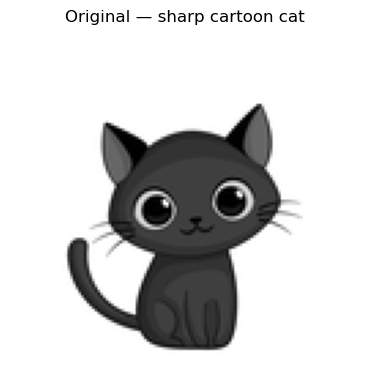

In [5]:
image_path = "cartoon_kitten.jpg"
img_size = 128

if not os.path.exists(image_path):
    print(f"Error: {image_path} not found.")
else:
    img = Image.open(image_path).convert('L').resize((img_size, img_size), Image.LANCZOS)
    u_true = np.array(img) / 255.0  

print(f"Image shape : {u_true.shape}  |  range: [{u_true.min():.2f}, {u_true.max():.2f}]")

plt.figure(figsize=(4, 4))
plt.imshow(u_true, cmap='gray', vmin=0, vmax=1)
plt.title('Original — sharp cartoon cat')
plt.axis('off')
plt.tight_layout()
plt.show()

## Apply Gaussian Blur and Build H


We need the blur type in the image to **match** the blur model in $H$. Since we build $H$ from a Gaussian kernel, we apply the same Gaussian blur to the image. This keeps the forward model consistent: $\mathbf{f} = H\mathbf{u}_{true}$.


σ = 1.5 produces a visible but recoverable blur — not too heavy, not too light. A 5×5 kernel captures 99%+ of the Gaussian mass at this sigma, so larger sizes add nothing.


Every row of $H$ sums to exactly 1 regardless of position. Boundary pixels get the same treatment as interior pixels — no edge artifacts.

Kernel : 5×5,  sigma=1.5,  sum=1.0000
H shape: (16384, 16384),  nnz: 409600


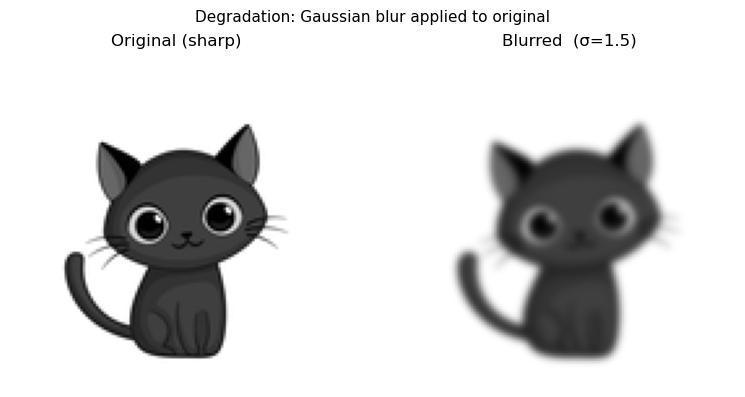

In [6]:
kernel_size = 5
sigma_value = 1.5

# The code below defines the Gaussian Kernel and the K Sparse Kernel.
kernel   = get_gaussian_kernel(size=kernel_size, sigma=sigma_value)
K_sparse = create_sparse_blur_matrix(u_true.shape, kernel)

f_img = gaussian_filter(u_true, sigma=sigma_value) 
f_vec = f_img.flatten(order='C')                  

print(f"Kernel : {kernel_size}×{kernel_size},  sigma={sigma_value},  sum={kernel.sum():.4f}")
print(f"H shape: {K_sparse.shape},  nnz: {K_sparse.nnz}")

fig, axes = plt.subplots(1, 2, figsize=(8, 4))
axes[0].imshow(u_true, cmap='gray', vmin=0, vmax=1)
axes[0].set_title('Original (sharp)')
axes[0].axis('off')
axes[1].imshow(f_img, cmap='gray', vmin=0, vmax=1)
axes[1].set_title(f'Blurred  (σ={sigma_value})')
axes[1].axis('off')
plt.suptitle('Degradation: Gaussian blur applied to original', fontsize=11)
plt.tight_layout()
plt.show()

## Solve with CVXPY

$$
\min_{\mathbf{u}}\; \underbrace{\|H\mathbf{u} - \mathbf{f}\|_2^2}_{\text{stay close to blurred input}} + \lambda\underbrace{\sum_{i,j}\|\nabla u_{i,j}\|_2}_{\text{keep edges sharp, regions flat}}
\quad\text{s.t.}\quad 0 \leq \mathbf{u} \leq 1
$$

**Why is this problem convex?**
$H$ is a fixed constant matrix, so $\|H\mathbf{u} - \mathbf{f}\|^2$ is a quadratic in $\mathbf{u}$ (convex). TV is also convex. Their sum is convex — CVXPY can solve it directly.

**What does λ control?**
- **Too small**: solution fits the blurred image too closely — stays blurry
- **Too large**: over-smoothed — loses edge detail
- **Just right**: sharp edges restored, flat regions smooth

We show all three panels per λ: original → blurred → deblurred.

In [ ]:
lambdas = [0.01, 0.025, 0.03, 0.05]

fig, axes = plt.subplots(len(lambdas), 3, figsize=(12, 4 * len(lambdas)))

for idx, LAMBDA_TV in enumerate(lambdas):
    U     = cp.Variable((img_size, img_size))
    U_vec = cp.reshape(U, (img_size * img_size,), order='C')  # row-major, matches H

    data_fidelity  = cp.sum_squares(K_sparse @ U_vec - f_vec)
    regularization = cp.tv(U)
    prob = cp.Problem(
        cp.Minimize(data_fidelity + LAMBDA_TV * regularization),
        [U >= 0, U <= 1]
    )
    prob.solve(solver=cp.SCS, verbose=False)

    u_recovered = np.clip(U.value, 0, 1)

    print(f"λ={LAMBDA_TV}  |  status: {prob.status}  |  "
          f"fidelity: {float(data_fidelity.value):.4f}  |  "
          f"TV: {float(regularization.value):.4f}")

    axes[idx, 0].imshow(u_true, cmap='gray', vmin=0, vmax=1)
    axes[idx, 0].set_title('Original Image')
    axes[idx, 0].axis('off')

    axes[idx, 1].imshow(f_img, cmap='gray', vmin=0, vmax=1)
    axes[idx, 1].set_title(f'Blurred Image (σ={sigma_value})')
    axes[idx, 1].axis('off')

    axes[idx, 2].imshow(u_recovered, cmap='gray', vmin=0, vmax=1)
    axes[idx, 2].set_title(f'Deblurred Image (λ={LAMBDA_TV})')
    axes[idx, 2].axis('off')

plt.suptitle('Original  →  Blurred  →  Deblurred', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('deblurred_results.png', dpi=150, bbox_inches='tight')
plt.show()

## Summary

**What we did:**
1. Loaded a sharp cartoon cat image — good fit for TV because it has flat regions and clean edges
2. Applied Gaussian blur (σ=1.5) to simulate degradation — same σ used to build H so the model is consistent
3. Solved one convex problem with CVXPY to recover the sharp image

**Why it works:**
- H is constant → problem is convex → CVXPY solves it directly, no iteration tricks needed
- TV regularization rewards flat regions and sharp edges — exactly what a cartoon has
- The model finds u that is both close to the blurred image (fidelity) and piecewise-smooth (TV)

**λ tradeoff:**

| λ | Effect |
|---|---|
| 0.01 | Closest to blurred input — least smoothing |
| 0.025 | Moderate recovery |
| 0.03 | Good balance for this image |
| 0.05 | Most smoothing — may soften fine edges |